In [71]:
import pandas as pd
import numpy as np


In [72]:
from statsmodels.stats.diagnostic import acorr_ljungbox

In [73]:
data=pd.read_csv("Electric_Production.csv")

In [74]:
data.head()

,DATE,IPG2211A2N
0,1/1/1985,72.5052
1,2/1/1985,70.6720
2,3/1/1985,62.4502
3,4/1/1985,57.4714
4,5/1/1985,55.3151


In [75]:
data['DATE']=pd.to_datetime(data['DATE'])

In [76]:
data

,DATE,IPG2211A2N
0,1985-01-01,72.5052
1,1985-02-01,70.6720
2,1985-03-01,62.4502
3,1985-04-01,57.4714
4,1985-05-01,55.3151
...,...,...
392,2017-09-01,98.6154
393,2017-10-01,93.6137
394,2017-11-01,97.3359
395,2017-12-01,114.7212


In [77]:
data.set_index('DATE',inplace=True)

In [78]:
data.head()

,IPG2211A2N
DATE,
1985-01-01,72.5052
1985-02-01,70.6720
1985-03-01,62.4502
1985-04-01,57.4714
1985-05-01,55.3151


In [79]:
data.isnull().sum()

IPG2211A2N    0
dtype: int64

<Axes: xlabel='DATE'>

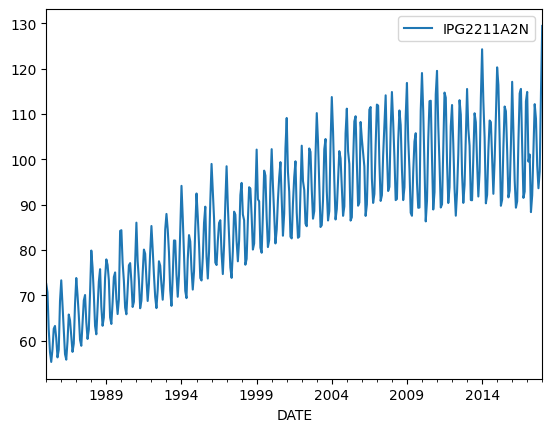

In [80]:
data.plot()

In [81]:
from statsmodels.tsa.stattools import adfuller,kpss

In [82]:
def adf_test(series):
    adf_test=adfuller(series)
    print(f"adf stats:{round(adf_test[0],3)}")
    print(f"p-value stats:{round(adf_test[1],3)}")
    print(f"lags values:{round(adf_test[2],3)}")
    for key,value in adf_test[4].items():
     print(f"{key}:{round(value,3)}")
        
def kpss_test(series):
    kpss_test=kpss(series,regression='ct')
    print("KPSS Statistic:", kpss_test[0])
    print("p-value:", kpss_test[1])
    print("Lags used:", kpss_test[2])
    print("Critical values:", kpss_test[3].items())
    

In [83]:
adf_test(data['IPG2211A2N'])

adf stats:-2.257
p-value stats:0.186
lags values:15
1%:-3.448
5%:-2.869
10%:-2.571


In [84]:
kpss_test(data['IPG2211A2N'])

KPSS Statistic: 0.5051030832418743
p-value: 0.01
Lags used: 16
Critical values: dict_items([('10%', 0.119), ('5%', 0.146), ('2.5%', 0.176), ('1%', 0.216)])


In [85]:
from statsmodels.graphics.tsaplots import plot_pacf,plot_acf

Figure(640x480)
Figure(640x480)


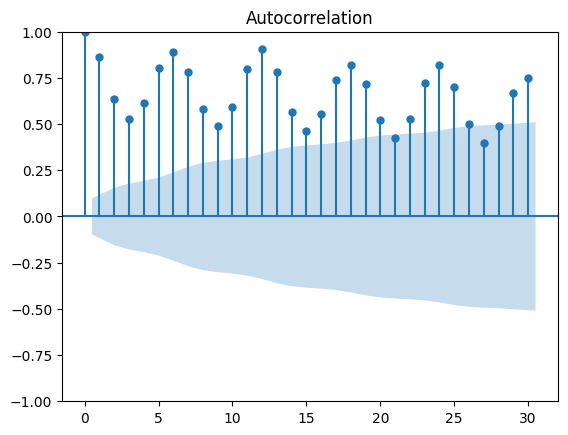

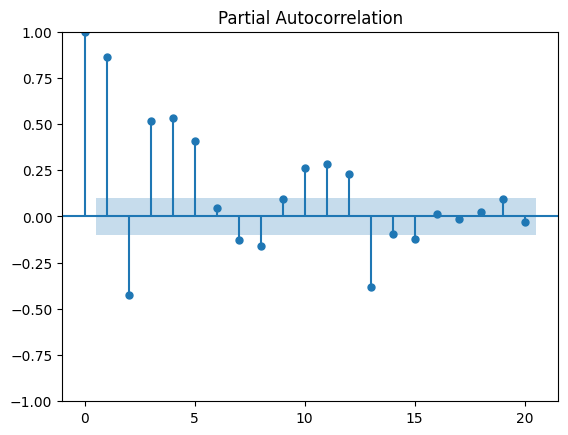

In [86]:
print(plot_acf(data['IPG2211A2N'],lags=30))
print(plot_pacf(data['IPG2211A2N'],lags=20))

In [18]:
#pacf order of autoregression model is 5 which is p.

In [87]:
from statsmodels.stats.diagnostic import acorr_ljungbox

In [88]:
result = acorr_ljungbox(data['IPG2211A2N'], lags=[20], return_df=True)

print(result)
print(result['lb_stat'])
print(result['lb_pvalue'])

        lb_stat  lb_pvalue
20  3970.708576        0.0
20    3970.708576
Name: lb_stat, dtype: float64
20    0.0
Name: lb_pvalue, dtype: float64


In [89]:
print(result['lb_pvalue'].iloc[0])

0.0


In [90]:
# Interpret the p-value
# p-value	Conclusion
# p > 0.05	Fail to reject H₀ → no significant autocorrelation detected ✅ #white noise
# p < 0.05	Reject H₀ → significant autocorrelation exists #so the series is not white noise.
# High p-value → good (no evidence of remaining autocorrelation)
# Low p-value → problem (remaining autocorrelation)

In [91]:
#White noise⇒no autocorrelation
if result['lb_pvalue'].iloc[0]<0.05:
    print('Reject H₀ → significant autocorrelation exists, random walk')
else:
    print('Fail to reject H₀ → no significant autocorrelation detected')

Reject H₀ → significant autocorrelation exists, no white noise


In [92]:
from statsmodels.tsa.arima.model import ARIMA

In [93]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 397 entries, 1985-01-01 to 2018-01-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   IPG2211A2N  397 non-null    float64
dtypes: float64(1)
memory usage: 6.2 KB


In [94]:
train=data[:300]
test=data[300:]

In [37]:
len(train),len(test)

(300, 97)

In [38]:
import warnings

warnings.filterwarnings('ignore')

In [39]:
q_values=np.arange(0,31,2)

In [31]:
for q in q_values:
    model = ARIMA(train, order=(0, 0, q)).fit()
    print(q, model.aic, model.bic)

0 2445.124248724906 2452.5318136742185
2 1975.140744923067 1989.9558748216916
4 1872.772405825548 1894.9951006734852
6 1884.4737523487183 1914.104012145968
8 1787.026925016783 1824.064749763345
10 1758.5726140655029 1803.0180037613773
12 1770.8158443311618 1822.6687989763486
14 1721.606908181948 1780.8674277764471
16 1696.672522602225 1763.3406071460365
18 1711.5643596652317 1785.6400091583557
20 1662.3583252583928 1743.8415397008293
22 1672.3594853829359 1761.2502647746846
24 1644.180756715747 1740.4791010568083
26 1639.0296690946966 1742.7355783850703
28 1673.802200471785 1784.915674711471
30 1625.221608644398 1743.7426478333964


In [85]:
# 1. Prepare data
#        ↓
# 2. Check stationarity (ADF / KPSS)
#        ↓
# 3. Look at ACF / PACF
#        ↓
# 4. Choose AR/MA/ARIMA order
#        ↓
# 5. Fit the model
#        ↓
# 6. Get residuals
#        ↓
# 7. Ljung–Box test  ← HERE
#        ↓
# 8. Check whether residuals are white noise
#in time-series modeling, a good final model ideally leaves white-noise-like residuals.

In [89]:
from statsmodels.tsa.ar_model import AutoReg

In [95]:
model = AutoReg(train, lags=5).fit()

residuals = model.resid

from statsmodels.stats.diagnostic import acorr_ljungbox

result = acorr_ljungbox(
    residuals,
    lags=[2],
    return_df=True
)

print(result)

    lb_stat  lb_pvalue
2  0.166959    0.91991


In [40]:
# Think of your original data as:
# Data=Predictable pattern+Random noise
# Your model tries to capture the predictable pattern.
# After fitting:
# Residual=Data−Model’s prediction
# Ideally:
# Residual≈White Noise
# because that means:
# The model extracted the predictable information, and what's left is essentially random.

In [96]:
copy_data=data.diff().dropna()


In [97]:
adf_test(copy_data['IPG2211A2N'])

adf stats:-7.105
p-value stats:0.0
lags values:14
1%:-3.448
5%:-2.869
10%:-2.571


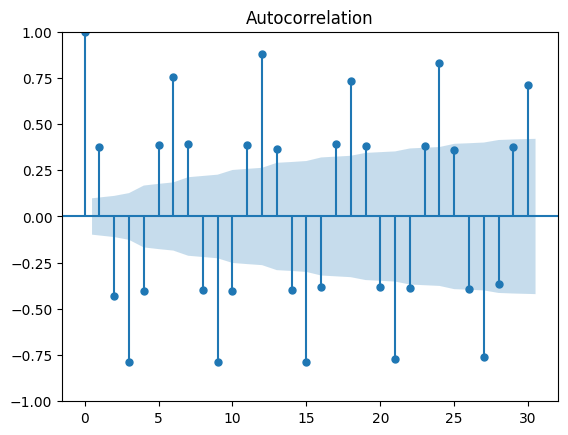

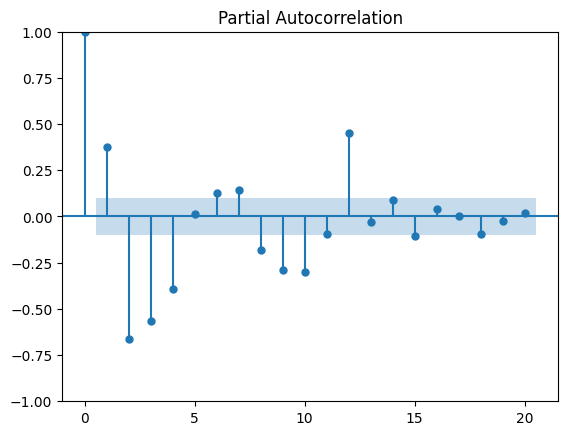

In [99]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
plot_acf(copy_data, lags=30)
plt.show()

plot_pacf(copy_data, lags=20)
plt.show()

In [100]:
train=copy_data[:300]
test=copy_data[300:]

In [101]:
model = ARIMA(train, order=(0, 0, 24))

In [102]:
model_fit=model.fit()

In [103]:
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:             IPG2211A2N   No. Observations:                  300
Model:                ARIMA(0, 0, 24)   Log Likelihood                -751.457
Date:                Wed, 26 Aug 2026   AIC                           1554.913
Time:                        19:00:52   BIC                           1651.212
Sample:                    02-01-1985   HQIC                          1593.452
                         - 01-01-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1382      0.024      5.673      0.000       0.090       0.186
ma.L1         -0.1265      0.058     -2.174      0.030      -0.241      -0.012
ma.L2         -0.4855      0.066     -7.396      0.0

In [104]:
residuals = model_fit.resid

from statsmodels.stats.diagnostic import acorr_ljungbox

result = acorr_ljungbox(
    residuals,
    lags=[10],
    return_df=True
)
print(result)

     lb_stat  lb_pvalue
10  3.494081   0.967299


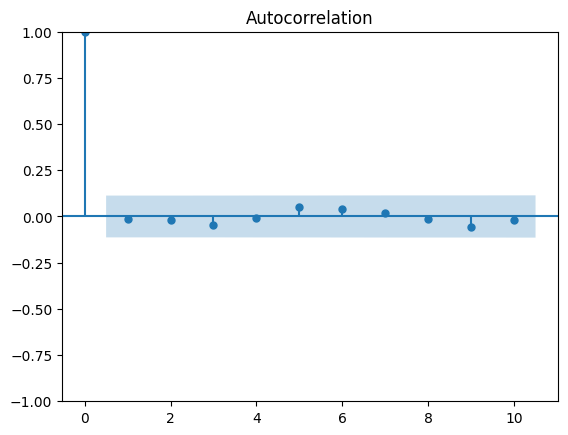

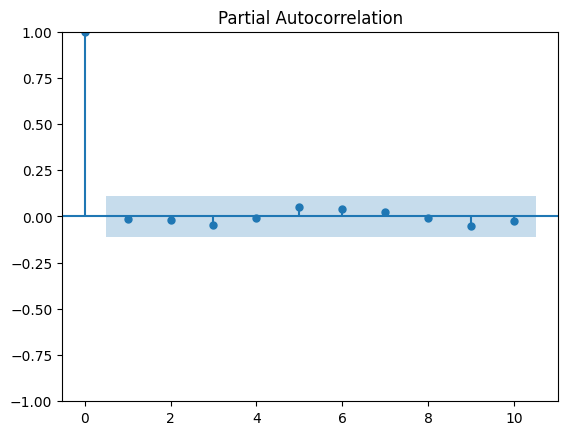

In [105]:
# There is no statistically significant evidence of autocorrelation in your residuals up to lag 10.
plot_acf(model_fit.resid, lags=10)
plt.show()

plot_pacf(model_fit.resid, lags=10)
plt.show()

In [106]:
model = ARIMA(train, order=(0, 0, 24))

In [107]:
model_fit=model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:             IPG2211A2N   No. Observations:                  300
Model:                ARIMA(0, 0, 24)   Log Likelihood                -751.457
Date:                Wed, 26 Aug 2026   AIC                           1554.913
Time:                        19:01:29   BIC                           1651.212
Sample:                    02-01-1985   HQIC                          1593.452
                         - 01-01-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1382      0.024      5.673      0.000       0.090       0.186
ma.L1         -0.1265      0.058     -2.174      0.030      -0.241      -0.012
ma.L2         -0.4855      0.066     -7.396      0.0

In [112]:
train_original=data[:300]
test_original=data[300:]

In [131]:
pred_diff = model_fit.predict(
    start=len(train),
    end=len(train)+len(test_original)-1
)
pred_diff


2010-02-01    -4.811634
2010-03-01    -3.782771
2010-04-01   -10.241204
2010-05-01    -3.053664
2010-06-01     5.483805
                ...    
2017-10-01     0.138212
2017-11-01     0.138212
2017-12-01     0.138212
2018-01-01     0.138212
2018-02-01     0.138212
Freq: MS, Name: predicted_mean, Length: 97, dtype: float64

In [132]:
print(pred_diff.isna().sum())
print(train_original.iloc[-1])




# train_original.iloc[-1]+pred_diff.cumsum()
# pred_original = train_original.iloc[-1] + pred_diff.cumsum()

# print(pred_original)


0
IPG2211A2N    110.6844
Name: 2009-12-01 00:00:00, dtype: float64


In [133]:
last_value = train_original.iloc[-1].item()
last_value

110.6844

In [134]:
pred_original = last_value + pred_diff.cumsum()

print(pred_original)

2010-02-01    105.872766
2010-03-01    102.089995
2010-04-01     91.848791
2010-05-01     88.795127
2010-06-01     94.278932
                 ...    
2017-10-01    105.971998
2017-11-01    106.110210
2017-12-01    106.248421
2018-01-01    106.386633
2018-02-01    106.524844
Freq: MS, Name: predicted_mean, Length: 97, dtype: float64


In [135]:
pred_original.shape,test_original.shape

((97,), (97, 1))

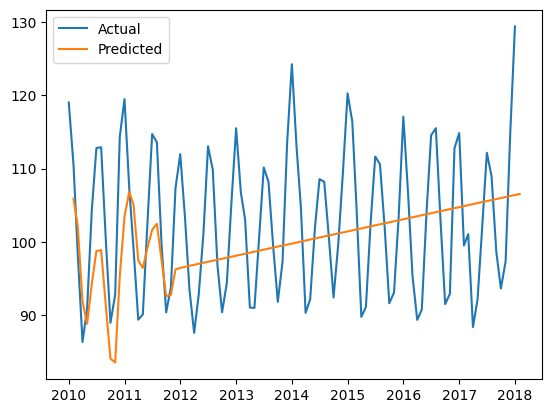

In [136]:
import matplotlib.pyplot as plt

plt.plot(test_original, label='Actual')
plt.plot(pred_original, label='Predicted')
plt.legend()
plt.show()

In [137]:
from sklearn.metrics import mean_squared_error

In [138]:
np.sqrt(mean_squared_error(test_original,pred_original))

np.float64(9.86781203768775)

In [141]:
pred_future_diff = model_fit.predict(
    start=len(copy_data),
    end=len(copy_data) + 6,
    dynamic=False
)

# Convert back to original scale
last_value = data.iloc[-1].item()

pred_future = last_value + pred_future_diff.cumsum()

print(pred_future)

2018-02-01    129.543012
2018-03-01    129.681223
2018-04-01    129.819435
2018-05-01    129.957646
2018-06-01    130.095858
2018-07-01    130.234069
2018-08-01    130.372281
Freq: MS, Name: predicted_mean, dtype: float64


In [142]:
pred_future

2018-02-01    129.543012
2018-03-01    129.681223
2018-04-01    129.819435
2018-05-01    129.957646
2018-06-01    130.095858
2018-07-01    130.234069
2018-08-01    130.372281
Freq: MS, Name: predicted_mean, dtype: float64

In [156]:
#ARMA

In [143]:
train_diff=copy_data[:300]
test_diff=copy_data[300:]

In [145]:
model = ARIMA(train_diff, order=(4, 0, 24)).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:             IPG2211A2N   No. Observations:                  300
Model:                ARIMA(4, 0, 24)   Log Likelihood                -687.427
Date:                Wed, 26 Aug 2026   AIC                           1434.854
Time:                        21:54:22   BIC                           1545.968
Sample:                    02-01-1985   HQIC                          1479.322
                         - 01-01-2010                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1393      0.016      8.563      0.000       0.107       0.171
ar.L1         -0.5510      0.107     -5.163      0.000      -0.760      -0.342
ar.L2         -0.2450      0.058     -4.214      0.000      -0.359      -0.131
ar.L3         -0.7548      0.057    -13.253      0.000      -0.866      -0.643
ar.L4         -0.7905      0.105     -7.521      0.000      -0.997      -0.585
ma.L1          0.1722      0.115      1.504      0.133      -0.052       0.397
ma.L2         -0.2903      0.105     -2.765      0.006      -0.496      -0.085
ma.L3          0.4713      0.092      5.137      0.000       0.291       0.651
ma.L4          0.3311      0.114      2.905      0.004       0.108       0.554
ma.L5         -0.7794      0.085     -9.161      0.000      -0.946      -0.613
ma.L6         -0.4858      0.104     -4.651      0.000      -0.690      -0.281
ma.L7         -0.1106      0.086     -1.283      0.200      -0.280       0.058
ma.L8         -0.2400      0.100     -2.392      0.017      -0.437      -0.043
ma.L9         -0.1048      0.101     -1.034      0.301      -0.304       0.094
ma.L10        -0.0148      0.112     -0.132      0.895      -0.234       0.204
ma.L11         0.0280      0.091      0.307      0.759      -0.151       0.207
ma.L12         0.5978      0.079      7.581      0.000       0.443       0.752
ma.L13         0.1046      0.117      0.896      0.370      -0.124       0.333
ma.L14        -0.1877      0.102     -1.834      0.067      -0.388       0.013
ma.L15         0.2225      0.101      2.207      0.027       0.025       0.420
ma.L16         0.1936      0.101      1.914      0.056      -0.005       0.392
ma.L17        -0.3091      0.094     -3.296      0.001      -0.493      -0.125
ma.L18        -0.3130      0.095     -3.280      0.001      -0.500      -0.126
ma.L19        -0.1604      0.094     -1.704      0.088      -0.345       0.024
ma.L20         0.0606      0.089      0.683      0.495      -0.113       0.235
ma.L21         0.0119      0.075      0.159      0.874      -0.135       0.159
ma.L22        -0.2459      0.076     -3.246      0.001      -0.394      -0.097
ma.L23         0.0395      0.068      0.582      0.561      -0.094       0.172
ma.L24         0.3429      0.074      4.653      0.000       0.198       0.487
sigma2         5.2838      0.466     11.338      0.000       4.370       6.197
===================================================================================
Ljung-Box (L1) (Q):                   0.32   Jarque-Bera (JB):                10.09
Prob(Q):                              0.57   Prob(JB):                         0.01
Heteroskedasticity (H):               1.80   Skew:                             0.35
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.55
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [153]:
pred = model.predict(
    start=len(train_diff),
    end=len(train_diff)+len(test_original)-1
)

In [154]:
last_value = train_original.iloc[-1].item()
last_value

110.6844

In [155]:
pred=last_value+pred.cumsum()

In [157]:
pred.shape,test_original.shape

((97,), (97, 1))

In [158]:
rmse = np.sqrt(mean_squared_error(test_original, pred))

print("RMSE:", rmse)

RMSE: 9.965694843194418


In [159]:
result = acorr_ljungbox(
    model.resid,
    lags=[10],
    return_df=True
)

print(result)

     lb_stat  lb_pvalue
10  5.563953   0.850472


In [ ]:
# For the Ljung–Box test, if you are checking whether your ARIMA residuals are white noise:

# You want the p-value to be greater than 0.05 ✅


In [ ]:
# Why test the residuals?

# After fitting ARIMA, we ideally want the residuals to behave like white noise:

# That means there should be no remaining autocorrelation.

# If residuals still have autocorrelation, it suggests:

# The model hasn't captured all the information/pattern in the original time series.

# So you may need to reconsider the ARIMA orders \(p,d,q\), seasonality, transformations, etc.
# Here, model.resid contains the residuals:

# $$ e_t = y_t-y_t_pred

# In other words:

# Residual = Actual value − Model's predicted value

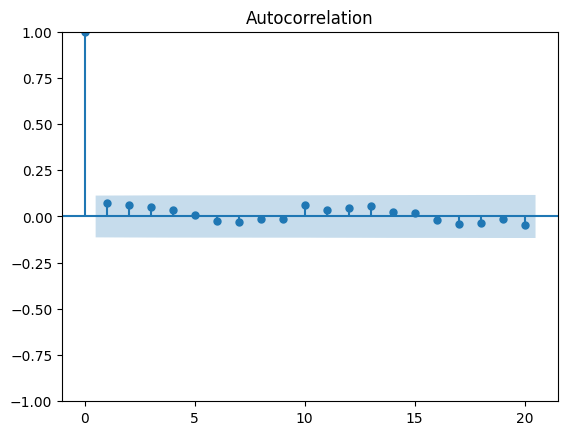

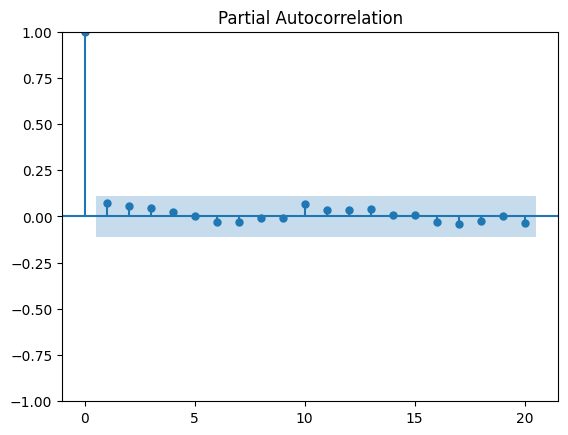

In [160]:
plot_acf(model.resid, lags=20)
plt.show()

plot_pacf(model.resid, lags=20)
plt.show()

In [161]:
model = ARIMA(train_diff, order=(12, 0, 24)).fit()

In [168]:
pred = model.predict(
    start=len(train_diff),
    end=len(train_diff)+len(test_original)-1
)
pred_test=train_original.iloc[-1].item()+pred.cumsum()

In [169]:
pred_test

2010-02-01    101.511920
2010-03-01     94.228927
2010-04-01     84.041628
2010-05-01     85.820859
2010-06-01     95.600557
                 ...    
2017-10-01     98.990999
2017-11-01    101.188980
2017-12-01    115.153808
2018-01-01    121.372821
2018-02-01    116.006395
Freq: MS, Name: predicted_mean, Length: 97, dtype: float64

In [170]:
pred_test

2010-02-01    101.511920
2010-03-01     94.228927
2010-04-01     84.041628
2010-05-01     85.820859
2010-06-01     95.600557
                 ...    
2017-10-01     98.990999
2017-11-01    101.188980
2017-12-01    115.153808
2018-01-01    121.372821
2018-02-01    116.006395
Freq: MS, Name: predicted_mean, Length: 97, dtype: float64

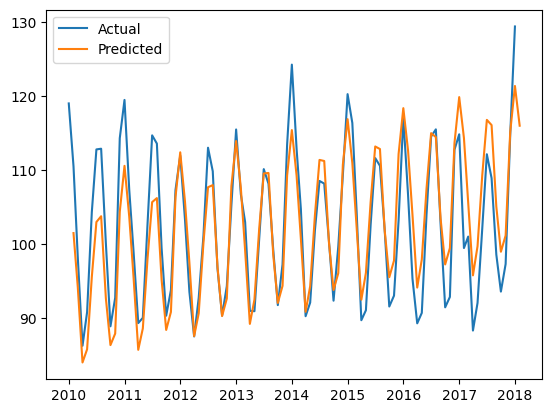

In [171]:
import matplotlib.pyplot as plt

plt.plot(test_original, label='Actual')
plt.plot(pred_test, label='Predicted')
plt.legend()
plt.show()

In [172]:
rmse = np.sqrt(mean_squared_error(test_original, pred_test))

print("RMSE:", rmse)

RMSE: 10.014279692965165


In [173]:
result = acorr_ljungbox(
    model.resid,
    lags=[10],
    return_df=True
)

print(result)

     lb_stat  lb_pvalue
10  3.805517   0.955694


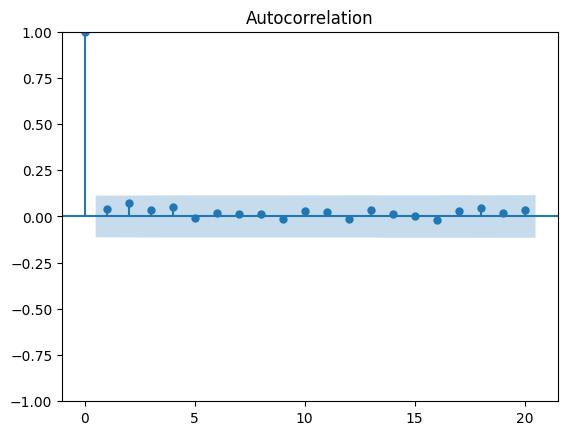

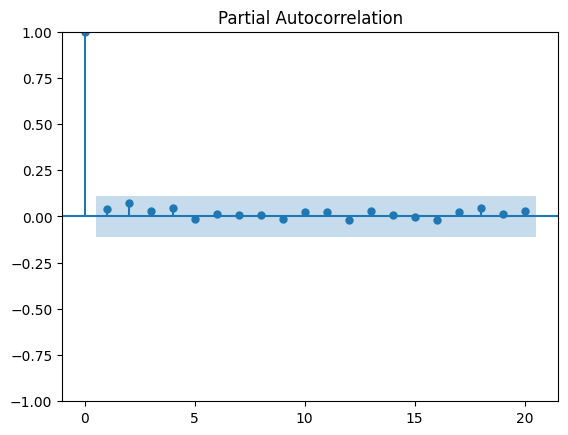

In [174]:
plot_acf(model.resid, lags=20)
plt.show()

plot_pacf(model.resid, lags=20)
plt.show()

In [177]:
pred_=model.predict(start=len(copy_data),end=len(copy_data)+6,dynamic=False)
pred_future=data.iloc[-1].item()+pred_

In [178]:
pred_future

2018-02-01    124.038373
2018-03-01    120.566492
2018-04-01    119.701088
2018-05-01    133.459493
2018-06-01    139.002027
2018-07-01    136.866489
2018-08-01    128.538644
Freq: MS, Name: predicted_mean, dtype: float64